<a href="https://colab.research.google.com/github/Fukash1/AI-Final-Project/blob/main/OriginalBalanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("engine_data_balanced.csv")
df

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,628,2.658460,5.623763,4.632760,74.614414,81.600788,1
1,1041,4.211048,5.424243,1.414678,77.093633,80.054223,0
2,958,2.115078,3.728559,2.878973,75.657365,77.901668,0
3,668,4.879405,5.445109,5.206547,78.270392,76.288946,0
4,1251,3.868864,9.566117,1.922281,77.990385,75.045938,0
...,...,...,...,...,...,...,...
14431,857,1.961509,6.952513,2.149182,77.384217,79.809504,0
14432,874,3.407218,13.944291,1.466438,77.807724,82.570965,1
14433,708,2.225990,1.558856,1.704898,77.716751,82.860729,0
14434,838,1.913384,4.816607,4.972876,77.512259,79.033032,0


In [3]:
#Rescaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

<Axes: >

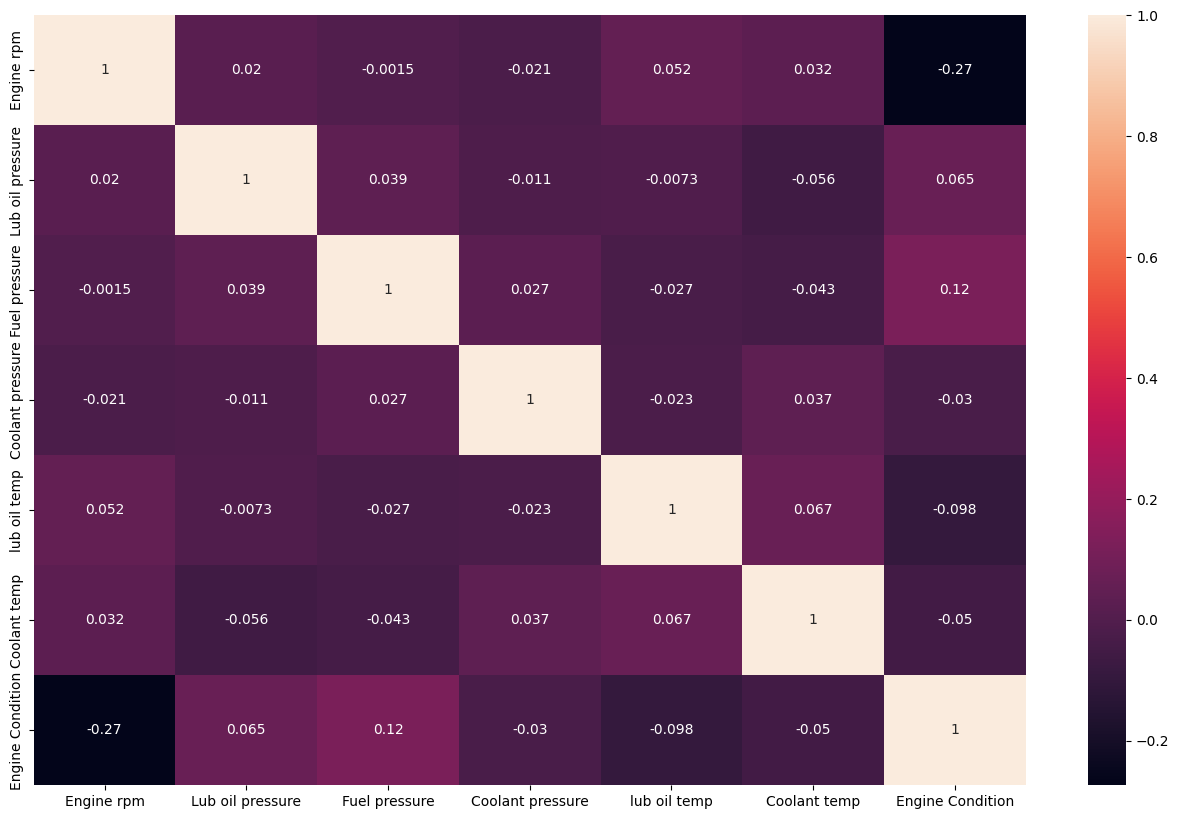

In [4]:
#Correletion matrix
import seaborn as sns
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True)

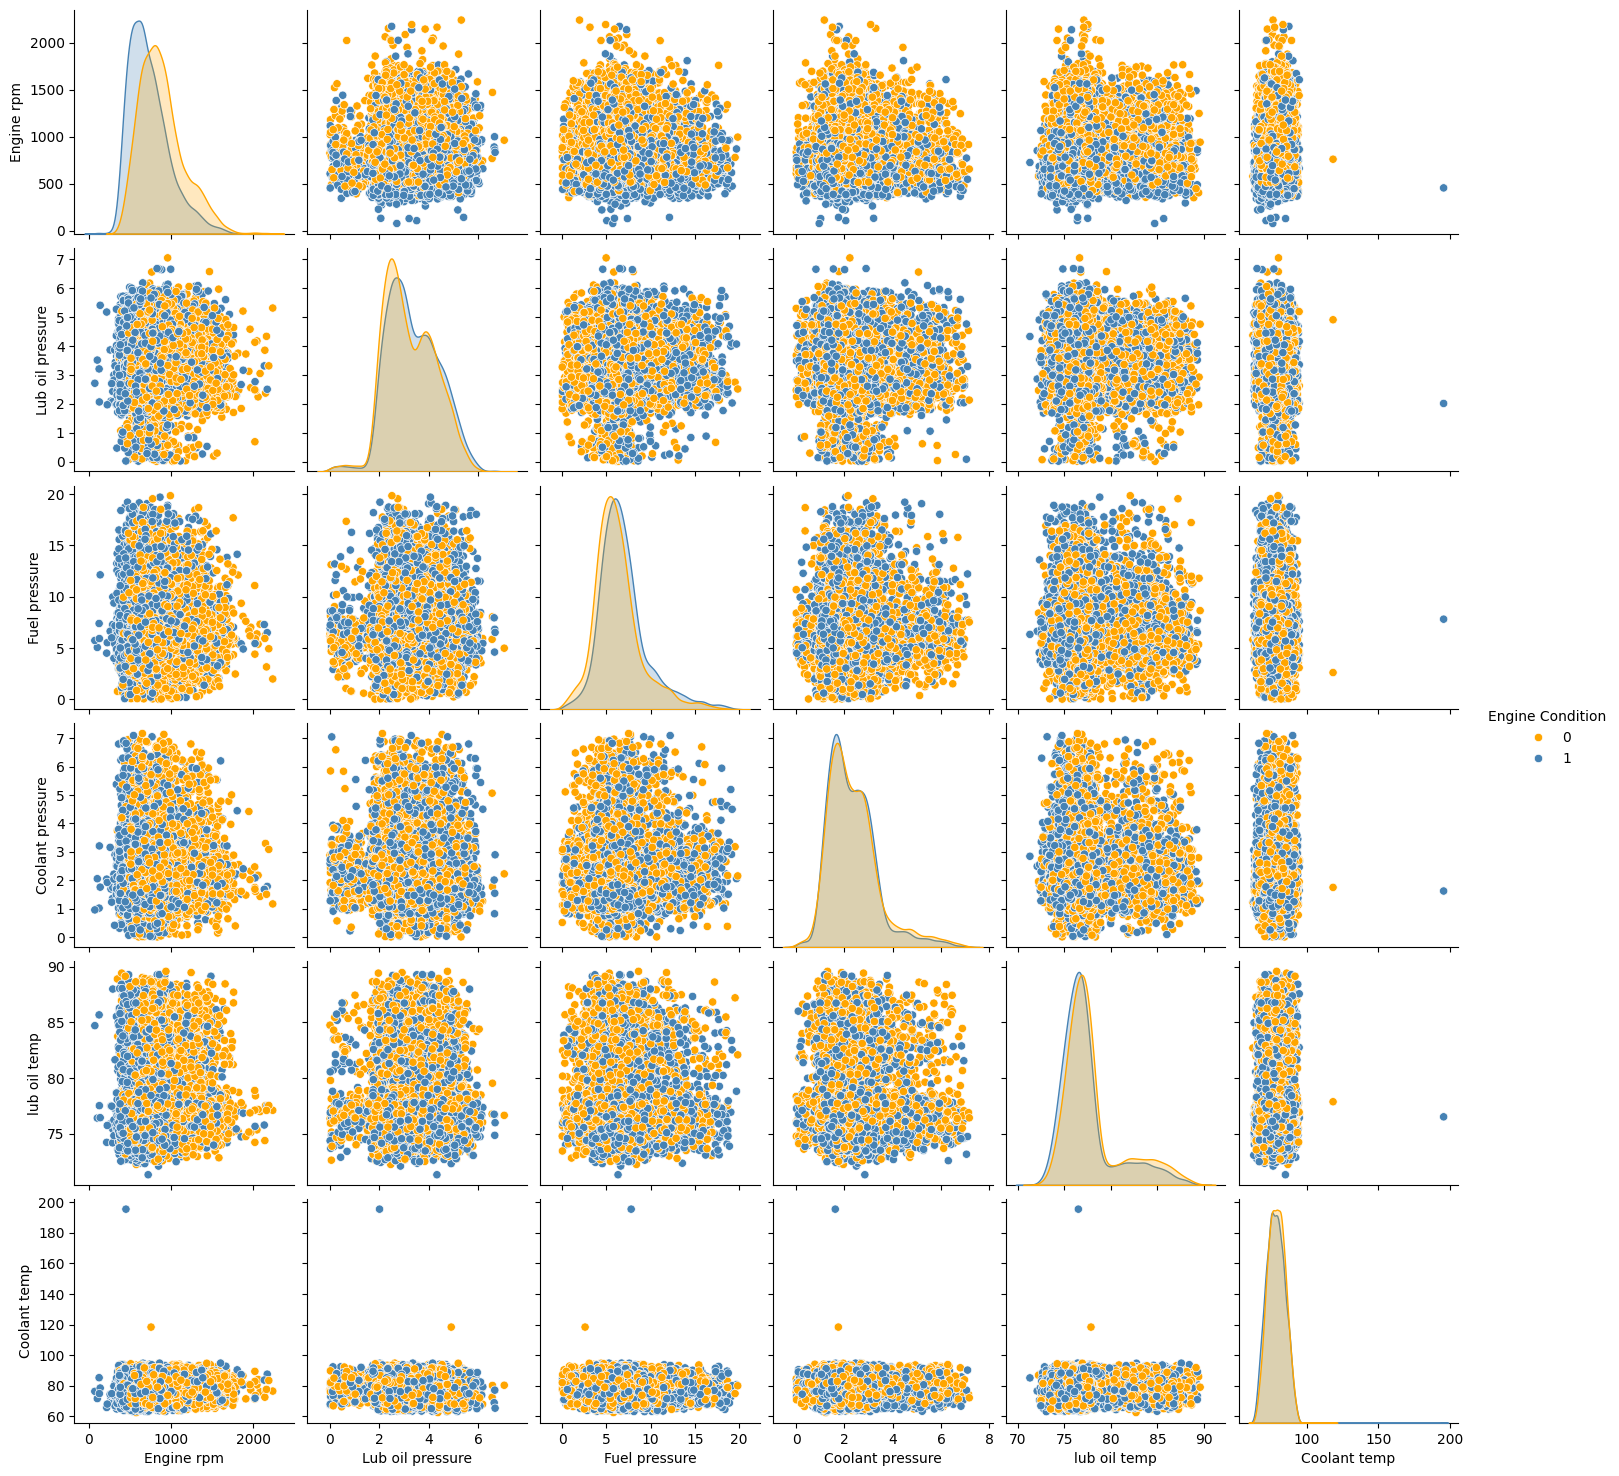

In [5]:
sns.pairplot(
    df,
    hue="Engine Condition",
    palette={0: "orange", 1: "steelblue"},
    diag_kind="kde"
)

In [6]:
x = df.drop('Engine Condition', axis=1)
y = df['Engine Condition']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return acc

--- Optimized Logistic Regression ---
Accuracy: 0.6354

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.60      0.62      1444
           1       0.63      0.67      0.65      1444

    accuracy                           0.64      2888
   macro avg       0.64      0.64      0.64      2888
weighted avg       0.64      0.64      0.64      2888



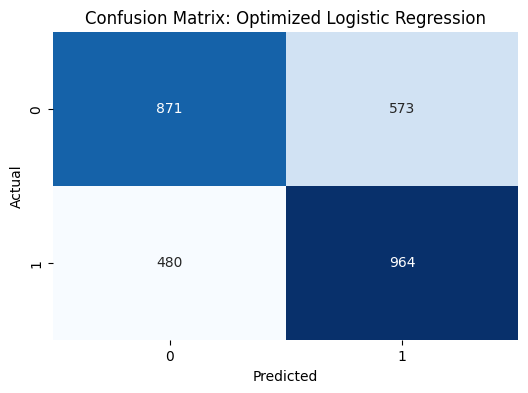

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 5],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(x_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

acc_lr = evaluate_model(
    best_lr,
    x_train_scaled,
    y_train,
    x_test_scaled,
    y_test,
    "Optimized Logistic Regression"
)

--- Optimized Random Forest ---
Accuracy: 0.6513

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67      1444
           1       0.67      0.60      0.63      1444

    accuracy                           0.65      2888
   macro avg       0.65      0.65      0.65      2888
weighted avg       0.65      0.65      0.65      2888



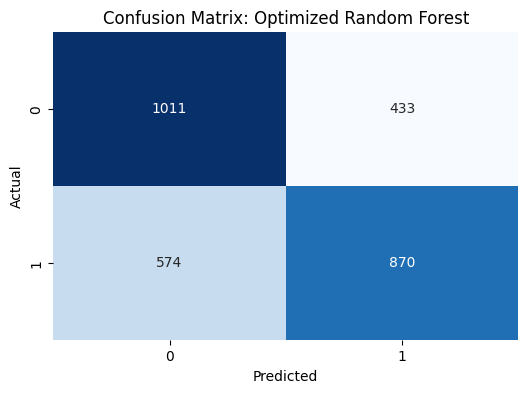

In [9]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(x_train_scaled, y_train)

best_rf = rf_grid.best_estimator_

acc_rf = evaluate_model(
    best_rf,
    x_train_scaled,
    y_train,
    x_test_scaled,
    y_test,
    "Optimized Random Forest"
)

--- Optimized Neural Network ---
Accuracy: 0.6492

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65      1444
           1       0.65      0.65      0.65      1444

    accuracy                           0.65      2888
   macro avg       0.65      0.65      0.65      2888
weighted avg       0.65      0.65      0.65      2888



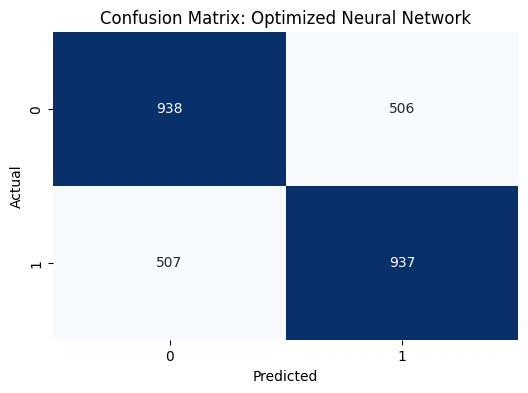

In [10]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    early_stopping=True, #prevent overfitting
    random_state=42
)

acc_mlp = evaluate_model(
    mlp_model,
    x_train_scaled,
    y_train,
    x_test_scaled,
    y_test,
    "Optimized Neural Network"
)

In [11]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [acc_lr, acc_rf, acc_mlp]
})

results
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
1        Random Forest  0.651316
2       Neural Network  0.649238
0  Logistic Regression  0.635388


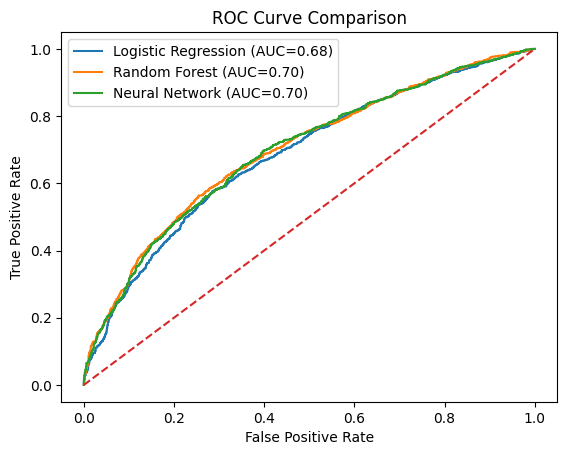

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure()

models = [
    (best_lr, "Logistic Regression"),
    (best_rf, "Random Forest"),
    (mlp_model, "Neural Network")
]

for model, name in models:
    y_prob = model.predict_proba(x_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

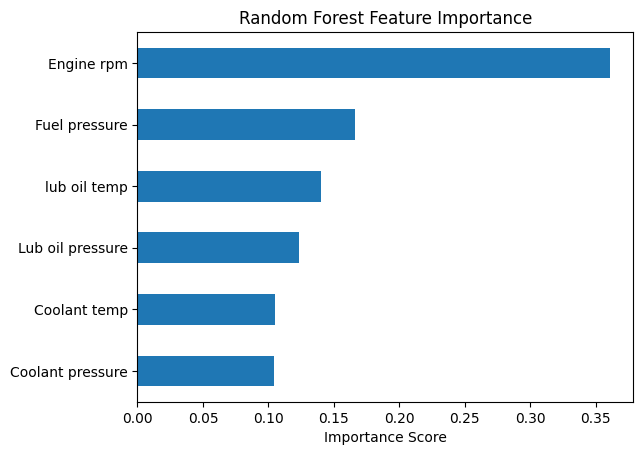

In [13]:
import pandas as pd

importances = best_rf.feature_importances_
feature_names = x.columns

feat_imp = pd.Series(importances, index=feature_names)

plt.figure()
feat_imp.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

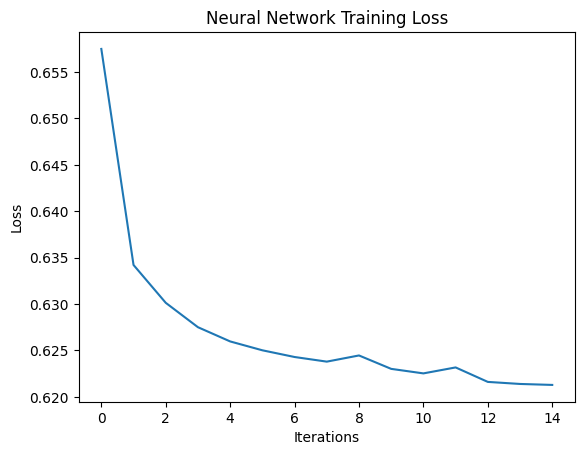

In [14]:
plt.figure()
plt.plot(mlp_model.loss_curve_)
plt.title("Neural Network Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

models = [
    (best_lr, "Logistic Regression"),
    (best_rf, "Random Forest"),
    (mlp_model, "Neural Network")
]

cv_results = {}

for model, name in models:
    scores = cross_val_score(model, x_train_scaled, y_train, cv=5)
    cv_results[name] = scores.mean()

cv_df = pd.DataFrame.from_dict(cv_results, orient='index', columns=['CV Accuracy'])
cv_df

,CV Accuracy
Logistic Regression,0.640976
Random Forest,0.644786
Neural Network,0.647557


In [16]:
y_prob = best_rf.predict_proba(x_test_scaled)[:,1]

thresholds = [0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.67      0.43      0.52      1444
           1       0.58      0.79      0.67      1444

    accuracy                           0.61      2888
   macro avg       0.63      0.61      0.60      2888
weighted avg       0.63      0.61      0.60      2888


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.64      0.70      0.67      1444
           1       0.67      0.60      0.63      1444

    accuracy                           0.65      2888
   macro avg       0.65      0.65      0.65      2888
weighted avg       0.65      0.65      0.65      2888


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.59      0.85      0.70      1444
           1       0.73      0.42      0.54      1444

    accuracy                           0.63      2888
   macro avg       0.66      0.63      0.62      2888
weighted avg       0.66   

In [17]:
print("Train Accuracy:", best_rf.score(x_train_scaled, y_train))
print("Test Accuracy:", best_rf.score(x_test_scaled, y_test))

Train Accuracy: 0.7686179425008659
Test Accuracy: 0.6513157894736842


In [18]:
def predict_engine_condition(model, scaler):

    print("===== Engine Health Prediction ====")
    print("\nRecommended Input Ranges:")
    print("Engine RPM: 600 – 2200")
    print("Lub oil pressure: 0.5 – 7")
    print("Fuel pressure: 1 – 20")
    print("Coolant pressure: 0.5 – 7")
    print("Lub oil temp: 60 – 120 °C")
    print("Coolant temp: 60 – 110 °C")

    print("\nEnter engine sensor values:")

    rpm = float(input("Engine RPM: "))
    oil_pressure = float(input("Lub oil pressure: "))
    fuel_pressure = float(input("Fuel pressure: "))
    coolant_pressure = float(input("Coolant pressure: "))
    oil_temp = float(input("Lub oil temp: "))
    coolant_temp = float(input("Coolant temp: "))

    input_data = pd.DataFrame([{
        "Engine rpm": rpm,
        "Lub oil pressure": oil_pressure,
        "Fuel pressure": fuel_pressure,
        "Coolant pressure": coolant_pressure,
        "lub oil temp": oil_temp,
        "Coolant temp": coolant_temp,
    }])

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    print("\n---- Prediction Result ----")

    if prediction == 1:
        print("Engine Fault Detected")
    else:
        print("Engine Healthy")

    print(f"Failure Probability: {probability*100:.2f}%")

In [25]:
predict_engine_condition(mlp_model, scaler)

===== Engine Health Prediction ====

Recommended Input Ranges:
Engine RPM: 600 – 2200
Lub oil pressure: 0.5 – 7
Fuel pressure: 1 – 20
Coolant pressure: 0.5 – 7
Lub oil temp: 60 – 120 °C
Coolant temp: 60 – 110 °C

Enter engine sensor values:
Engine RPM: 600
Lub oil pressure: 5
Fuel pressure: 15
Coolant pressure: 5
Lub oil temp: 110
Coolant temp: 100

---- Prediction Result ----
Engine Fault Detected
Failure Probability: 50.76%
